# Wind Power Forecasting — Naive Baseline vs. XGBoost

Goal: forecast turbine power **1 hour ahead** and check whether XGBoost beats a simple baseline.

Input: `data/processed/wind_features.csv` (built in notebook 03).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# Load the processed features, with timestamp as a datetime index
wind_df = pd.read_csv('../data/processed/wind_features.csv', index_col='timestamp', parse_dates=True)

TARGET = 'target_power_1h'
FEATURES = [col for col in wind_df.columns if col != TARGET]

print('Rows:', len(wind_df))
print('Number of features:', len(FEATURES))

Rows: 49706
Number of features: 23


## Time-Based Split

The data is split by date, never randomly, so the model is always tested on a period after the one it trained on:

| Set | Period | Purpose |
|---|---|---|
| Train | Jan – Aug | Learn patterns |
| Validation | Sep – Oct | Decide when to stop training (early stopping) |
| Test | Nov – Dec | Final, untouched evaluation |

In [6]:
train = wind_df[wind_df.index < '2018-09-01']
val = wind_df[(wind_df.index >= '2018-09-01') & (wind_df.index < '2018-11-01')]
test = wind_df[wind_df.index >= '2018-11-01']

X_train, y_train = train[FEATURES], train[TARGET]
X_val, y_val = val[FEATURES], val[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f'Train: {len(train)} rows ({train.index.min().date()} to {train.index.max().date()})')
print(f'Val:   {len(val)} rows ({val.index.min().date()} to {val.index.max().date()})')
print(f'Test:  {len(test)} rows ({test.index.min().date()} to {test.index.max().date()})')

Train: 33727 rows (2018-01-02 to 2018-08-31)
Val:   7894 rows (2018-09-01 to 2018-10-31)
Test:  8085 rows (2018-11-01 to 2018-12-31)


## Evaluation Metrics

- **MAE (Mean Absolute Error):** the average size of the error in kW. Easy to explain.
- **RMSE (Root Mean Squared Error):** like MAE, but penalises large misses more heavily.
- **Skill score:** how much a model improves on the naive baseline: `1 − RMSE_model / RMSE_naive`. A score of 0 means no better than the baseline; 0.2 means 20% lower error. This is the standard way to report wind forecast quality.

In [8]:
results = []

def evaluate(y_true, y_pred, model_name):
    """Compute MAE and RMSE for one model and store them in the results list."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    results.append({'Model': model_name, 'MAE (kW)': round(mae, 1), 'RMSE (kW)': round(rmse, 1)})
    print(f'{model_name}: MAE = {mae:.1f} kW, RMSE = {rmse:.1f} kW')

## Naive Baseline: Persistence

The simplest forecast: **power 1 hour from now = power right now.** It's called a persistence forecast, and it's surprisingly hard to beat over short horizons, because wind conditions usually don't change drastically within an hour.

A "same time yesterday" baseline isn't used, because EDA showed wind power has no daily cycle.

In [9]:
# Persistence forecast: the current power reading is the prediction for 1 hour ahead
naive_pred = X_test['power']
evaluate(y_test, naive_pred, 'Naive (persistence)')

Naive (persistence): MAE = 287.0 kW, RMSE = 496.2 kW


## Train XGBoost

XGBoost builds many small decision trees, each one correcting the errors of the previous ones.

- **Early stopping:** training stops once the error on the validation set stops improving for 50 rounds, which prevents overfitting.
- `subsample` and `colsample_bytree` train each tree on a random 80% of rows and features, which also reduces overfitting.

In [10]:
xgb_model = XGBRegressor(
    n_estimators=1000,          # upper limit; early stopping picks the actual number
    learning_rate=0.05,         # small steps = more careful learning
    max_depth=6,                # how complex each tree can be
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=42
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],  # monitor validation error during training
    verbose=100                 # print progress every 100 rounds
)

print('Best number of trees:', xgb_model.best_iteration + 1)

[0]	validation_0-rmse:1224.99002
[100]	validation_0-rmse:473.74491
[129]	validation_0-rmse:476.90239
Best number of trees: 80


## Evaluate on the Test Set

Predictions are clipped at 0, because the turbine can't generate negative power.

In [11]:
xgb_pred = np.clip(xgb_model.predict(X_test), 0, None)
evaluate(y_test, xgb_pred, 'XGBoost')

# Comparison table with skill score relative to the naive baseline
results_df = pd.DataFrame(results)
naive_rmse = results_df.loc[results_df['Model'] == 'Naive (persistence)', 'RMSE (kW)'].values[0]
results_df['Skill vs. naive'] = (1 - results_df['RMSE (kW)'] / naive_rmse).round(3)
results_df

XGBoost: MAE = 332.1 kW, RMSE = 489.7 kW


,Model,MAE (kW),RMSE (kW),Skill vs. naive
0,Naive (persistence),287.0,496.2,0.000
1,XGBoost,332.1,489.7,0.013


## Forecast vs. Actual (First Week of Test Period)

A visual check of how closely the forecasts follow real output.

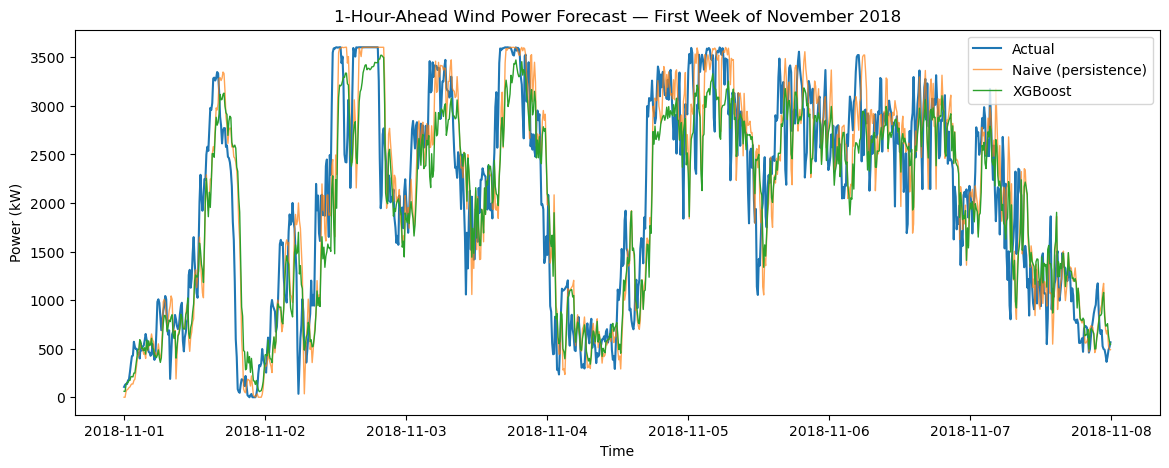

In [12]:
# Select the first 7 days of the test period
week = test.index < test.index[0] + pd.Timedelta(days=7)

plt.figure(figsize=(14, 5))
plt.plot(test.index[week], y_test[week], label='Actual', linewidth=1.5)
plt.plot(test.index[week], naive_pred[week], label='Naive (persistence)', linewidth=1, alpha=0.7)
plt.plot(test.index[week], xgb_pred[week], label='XGBoost', linewidth=1)
plt.title('1-Hour-Ahead Wind Power Forecast — First Week of November 2018')
plt.xlabel('Time')
plt.ylabel('Power (kW)')
plt.legend()
plt.show()

## Feature Importance

Which features XGBoost relied on most. This shows *what* drives the forecast, not just how accurate it is.

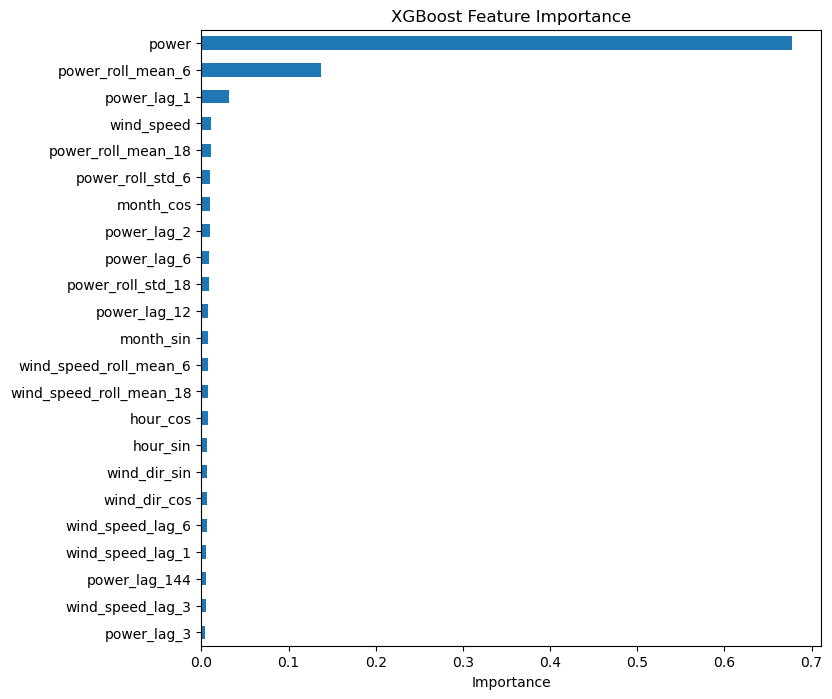

In [13]:
importance = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(8, 8))
importance.plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.show()

## Improvement: Forecast the Change, Not the Level

**Finding:** the first XGBoost model barely beat the persistence baseline (skill ≈ 0.01) and had a *higher* MAE. Tree models predict in steps, so they struggle to reproduce "the current value" exactly, which adds small errors even when the wind is steady.

**Fix:** instead of predicting power 1 hour ahead directly, predict the **change** in power over the next hour, then add it to the current power:

`forecast = current power + predicted change`

A predicted change of 0 is exactly the persistence forecast, so the model starts from the baseline and only has to learn when power will rise or fall. Trend features (how fast power and wind speed have been changing) are added to help it spot those shifts.

In [15]:
def add_trend_features(df):
    """Add features describing how fast power and wind speed have been changing."""
    df = df.copy()
    df['power_diff_1'] = df['power'] - df['power_lag_1']                  # change over the last 10 min
    df['power_diff_6'] = df['power'] - df['power_lag_6']                  # change over the last hour
    df['wind_speed_diff_1'] = df['wind_speed'] - df['wind_speed_lag_1']
    df['wind_speed_diff_6'] = df['wind_speed'] - df['wind_speed_lag_6']
    return df

train_v2 = add_trend_features(train)
val_v2 = add_trend_features(val)
test_v2 = add_trend_features(test)

FEATURES_V2 = [col for col in train_v2.columns if col != TARGET]

# New target: the change in power over the next hour
y_train_delta = train_v2[TARGET] - train_v2['power']
y_val_delta = val_v2[TARGET] - val_v2['power']

print('Number of features:', len(FEATURES_V2))

Number of features: 27


In [16]:
xgb_delta = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=42
)

xgb_delta.fit(
    train_v2[FEATURES_V2], y_train_delta,
    eval_set=[(val_v2[FEATURES_V2], y_val_delta)],
    verbose=100
)

print('Best number of trees:', xgb_delta.best_iteration + 1)

[0]	validation_0-rmse:485.87942
[100]	validation_0-rmse:470.26277
[111]	validation_0-rmse:471.33513
Best number of trees: 62


In [17]:
# Forecast = current power + predicted change,
# clipped between 0 and the turbine's maximum observed output
delta_pred = xgb_delta.predict(test_v2[FEATURES_V2])
xgb_delta_pred = np.clip(test_v2['power'] + delta_pred, 0, train['power'].max())

evaluate(y_test, xgb_delta_pred, 'XGBoost (predicts change)')

# Rebuild the comparison table with all three models
results_df = pd.DataFrame(results)
naive_rmse = results_df.loc[results_df['Model'] == 'Naive (persistence)', 'RMSE (kW)'].values[0]
results_df['Skill vs. naive'] = (1 - results_df['RMSE (kW)'] / naive_rmse).round(3)
results_df

XGBoost (predicts change): MAE = 312.2 kW, RMSE = 479.1 kW


,Model,MAE (kW),RMSE (kW),Skill vs. naive
0,Naive (persistence),287.0,496.2,0.000
1,XGBoost,332.1,489.7,0.013
2,XGBoost (predicts change),312.2,479.1,0.034


## Forecast vs. Actual — Improved Model (First Week of Test Period)

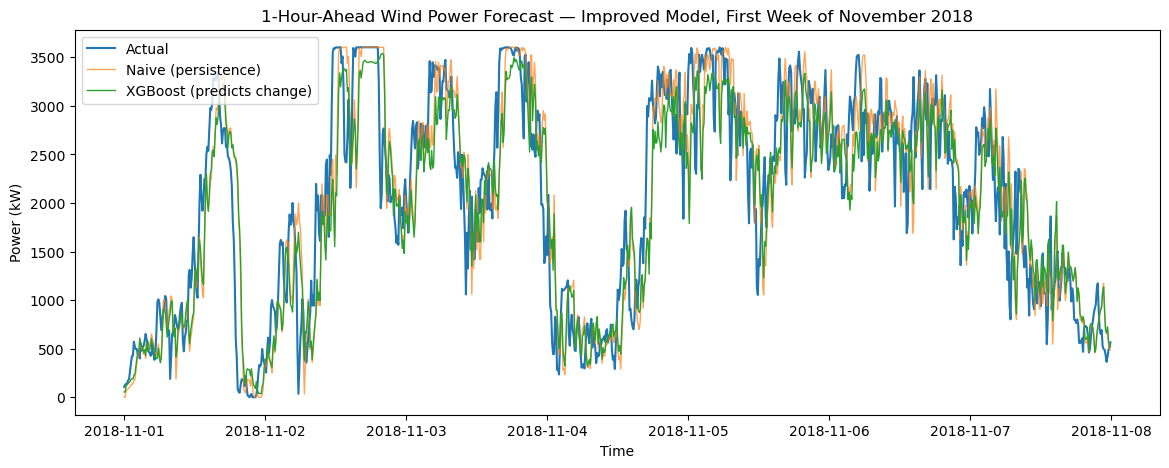

In [18]:
plt.figure(figsize=(14, 5))
plt.plot(test.index[week], y_test[week], label='Actual', linewidth=1.5)
plt.plot(test.index[week], naive_pred[week], label='Naive (persistence)', linewidth=1, alpha=0.7)
plt.plot(test.index[week], xgb_delta_pred[week], label='XGBoost (predicts change)', linewidth=1)
plt.title('1-Hour-Ahead Wind Power Forecast — Improved Model, First Week of November 2018')
plt.xlabel('Time')
plt.ylabel('Power (kW)')
plt.legend()
plt.show()

## Improvement 2: Optimise for Absolute Error

**Finding:** predicting the change improved skill (0.013 → 0.034), but MAE was still worse than persistence.

**Why:** the default squared-error objective pulls predictions toward the *average* change. Wind power changes are skewed: most hours barely change, but rare large drops (turbine stops, wind dies) shift the average away from zero. In steady hours the model therefore predicts a small change where persistence is almost exact, which increases MAE.

**Fix:** train with an **absolute-error** objective, so the model predicts the *median* change, which is close to zero in steady conditions. Squared error favours RMSE and absolute error favours MAE, so both variants are compared.

**Model selection is done on the validation set**; the test set is only used to report final results.

In [19]:
xgb_delta_mae = XGBRegressor(
    objective='reg:absoluteerror',   # optimise MAE instead of squared error
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=42
)

xgb_delta_mae.fit(
    train_v2[FEATURES_V2], y_train_delta,
    eval_set=[(val_v2[FEATURES_V2], y_val_delta)],
    verbose=100
)

print('Best number of trees:', xgb_delta_mae.best_iteration + 1)

[0]	validation_0-mae:312.12005
[100]	validation_0-mae:311.14881
[117]	validation_0-mae:311.30976
Best number of trees: 68


## Model Selection on the Validation Set

In [20]:
def val_scores(pred, name):
    """MAE and RMSE on the validation set (used for choosing between models)."""
    y_true = val[TARGET]
    return {'Model': name,
            'Val MAE (kW)': round(mean_absolute_error(y_true, pred), 1),
            'Val RMSE (kW)': round(np.sqrt(mean_squared_error(y_true, pred)), 1)}

max_power = train['power'].max()

val_table = pd.DataFrame([
    val_scores(val['power'], 'Naive (persistence)'),
    val_scores(np.clip(xgb_model.predict(X_val), 0, None), 'XGBoost'),
    val_scores(np.clip(val_v2['power'] + xgb_delta.predict(val_v2[FEATURES_V2]), 0, max_power),
               'XGBoost (predicts change)'),
    val_scores(np.clip(val_v2['power'] + xgb_delta_mae.predict(val_v2[FEATURES_V2]), 0, max_power),
               'XGBoost (change, MAE objective)'),
])
val_table

,Model,Val MAE (kW),Val RMSE (kW)
0,Naive (persistence),312.3,487.2
1,XGBoost,330.5,472.1
2,XGBoost (predicts change),317.4,466.8
3,"XGBoost (change, MAE objective)",310.4,471.1


## Final Test Results

In [21]:
xgb_delta_mae_pred = np.clip(test_v2['power'] + xgb_delta_mae.predict(test_v2[FEATURES_V2]), 0, max_power)
evaluate(y_test, xgb_delta_mae_pred, 'XGBoost (change, MAE objective)')

results_df = pd.DataFrame(results)
naive_rmse = results_df.loc[results_df['Model'] == 'Naive (persistence)', 'RMSE (kW)'].values[0]
results_df['Skill vs. naive'] = (1 - results_df['RMSE (kW)'] / naive_rmse).round(3)
results_df

XGBoost (change, MAE objective): MAE = 294.7 kW, RMSE = 483.6 kW


,Model,MAE (kW),RMSE (kW),Skill vs. naive
0,Naive (persistence),287.0,496.2,0.000
1,XGBoost,332.1,489.7,0.013
2,XGBoost (predicts change),312.2,479.1,0.034
3,"XGBoost (change, MAE objective)",294.7,483.6,0.025


## Results & Model Choice

Models were compared on the **validation set** using **RMSE** as the primary metric (the standard in wind forecasting, since large misses are the costliest for grid balancing). The test set was used only to report final results.

**Test results (Nov–Dec 2018):**

| Model | MAE (kW) | RMSE (kW) | Skill vs. naive |
|---|---|---|---|
| Naive (persistence) | 287.0 | 496.2 | 0.000 |
| XGBoost (predicts level) | 332.1 | 489.7 | 0.013 |
| **XGBoost (predicts change) ✅ selected** | 312.2 | **479.1** | **0.034** |
| XGBoost (change, MAE objective) | 294.7 | 483.6 | 0.025 |

**Key findings:**
1. **Persistence is a strong baseline** at a 1-hour horizon: wind conditions rarely change drastically within an hour.
2. **Predicting the change instead of the level** more than doubled the skill score (0.013 → 0.034), because the model starts from persistence and only learns deviations from it.
3. **The loss function is a trade-off:** optimising absolute error lowered MAE but raised RMSE. The margin by which it beat persistence on validation MAE did not hold on the test set, which shows why model selection must use validation data only.
4. **Past observations alone give limited gains:** the selected model reduces RMSE by about 3.4% compared with persistence. Larger improvements would likely require weather-forecast inputs (predicted wind speed), which aren't available for this dataset.

In [22]:
import json

# Save the selected model
xgb_delta.save_model('../models/wind_xgboost_delta.json')

# Save the exact feature list the model expects (needed by the dashboard later)
with open('../models/wind_xgboost_features.json', 'w') as f:
    json.dump(FEATURES_V2, f)

# Save test-set predictions so the LSTM can be compared on exactly the same rows
pd.DataFrame({
    'actual': y_test,
    'naive': naive_pred,
    'xgboost_delta': xgb_delta_pred
}, index=test.index).to_csv('../data/processed/wind_test_predictions.csv')

print('Saved model, feature list, and test predictions.')

Saved model, feature list, and test predictions.
